# Phase 5 — Municipal Typology, Vulnerability Scoring & Net Migration Modeling

This notebook extends the forecasting workflow into a planner-facing **municipal typology layer**.

Compared with the earlier version, this notebook now adds:

- **recent-year snapshot diagnostics** so the latest-year cross-section is not treated as automatically representative
- a **robust 0–1 vulnerability score** based on percentile clipping before rescaling
- **correlation screening** to reduce redundant clustering variables
- **K-means model selection diagnostics** using both inertia and silhouette scores
- an **interpretability guardrail** that prefers a parsimonious non-singleton solution when the top-silhouette alternative is only marginally better
- **cluster stability checks** across random seeds
- **hierarchical clustering comparison** to see whether broad groupings are consistent across methods
- **cluster profiling with ANOVA-style mean-difference tests**
- a **migration module** that runs when births/deaths are available and otherwise records an explicit deferred status

The goal is not to claim a single “true” municipal taxonomy.  
Instead, the notebook builds a transparent and defensible typology layer that can support the dashboard, the written paper, and follow-on case selection.


## 1. Load libraries and processed data


In [1]:

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.linear_model import LinearRegression
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import f_oneway

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

analysis_dir = Path(".")

candidate_paths = [
    Path("../data/processed_puerto_rico_data.csv"),
    Path("data/processed_puerto_rico_data.csv"),
    Path("./processed_puerto_rico_data.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find processed dataset. Checked: " + ", ".join(str(p) for p in candidate_paths)
    )

df = pd.read_csv(data_path)
print("Processed data path:", data_path)
print("Processed data shape:", df.shape)
df.head()


Processed data path: ../data/processed_puerto_rico_data.csv
Processed data shape: (936, 67)


,year,municipio,geoid,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,unemployment_rate_pct,unemployment_rate_moe,labor_force_participation_pct,labor_force_participation_moe,median_income_nominal,median_income_real,median_income_moe,cpi,total_population_25plus,hs_graduate_pct,hs_graduate_count,hs_graduate_moe,bachelors_plus_pct,bachelors_count,doctorate_count,doctorate_moe,establishment_count,uninsured_pct,uninsured_moe,poverty_rate_pct,unemployment_rate_pct.1,per_capita_income,no_hs_diploma_pct,under_18_pct,over_65_pct,disability_pct,single_parent_pct,minority_pct,limited_english_pct,multi_unit_housing_pct,mobile_homes_pct,crowding_pct,no_vehicle_pct,group_quarters_count,pct_group_quarters,lat,lon,max_wind_knots,max_seismic_mag,murder,robbery,burglary,larceny / theft,total,murder_rate,robbery_rate,burglary_rate,target_pop_change,lag_violent_crime_rate,lag_property_crime_rate,lag_pop_change_1,lag_pop_change_2,income_growth,per_capita_income_inv,split,vulnerability_index,svi_x_wind,svi_x_quake
0,2013,Adjuntas,72001,19334,0,15087,79,7298,140,27.200,0,39.6,0,11528,16161.74,1354,232.95,12518,59.6,3075,304.396123,15.6,1954,39,38.0,130.0,90.1,2.0,60.19,27.19,7235,41.03,24.90,14.47,22.51,12.30,99.42,14.69,3.55,0.00,4.94,22.16,65,0.34,18.1627,-66.7222,-0.000000,-0.0,0.0,9.0,62.0,109.0,198.0,0.000000,0.465501,3.206786,-0.637270,0.411142,5.550416,-0.286973,-0.138171,-13.238321,-7235.0,train,0.923610,-0.000000,-0.0
1,2014,Adjuntas,72001,19188,0,15080,88,7514,136,34.000,0,42.4,0,10550,14555.49,1358,236.72,12567,58.9,3220,334.977611,16.1,2018,70,55.0,128.0,90.8,1.8,62.07,34.05,7042,41.71,24.24,15.14,19.90,12.85,99.82,13.76,3.46,0.00,5.21,20.51,72,0.38,18.1627,-66.7222,2.219088,-0.0,0.0,6.0,32.0,69.0,117.0,0.000000,0.312695,1.667709,-0.755146,0.465501,3.206786,-0.637270,-0.286973,-9.938596,-7042.0,train,0.941412,2.089076,-0.0
2,2015,Adjuntas,72001,18962,0,15022,85,7694,126,35.108,0,42.9,0,10499,14467.60,1326,237.00,12556,62.0,3325,294.268585,17.1,2148,65,48.0,124.0,7.8,2.0,61.70,36.50,7270,38.60,23.66,15.80,20.25,13.89,99.79,13.56,3.41,0.35,4.56,19.25,70,0.37,18.1627,-66.7222,2.255385,-0.0,1.0,2.0,36.0,40.0,95.0,0.052737,0.105474,1.898534,-1.177819,0.312695,1.667709,-0.755146,-0.637270,-0.603827,-7270.0,train,0.903995,2.038857,-0.0
3,2016,Adjuntas,72001,18760,0,14963,78,7673,143,35.108,0,42.3,0,11296,15371.06,1218,240.01,12590,62.4,3105,309.401034,18.6,2342,71,48.0,119.0,6.9,1.9,63.01,35.62,7124,38.20,22.96,16.55,20.58,15.16,99.85,0.00,3.17,0.42,4.03,19.05,71,0.38,18.1627,-66.7222,-0.000000,-0.0,0.0,20.0,30.0,28.0,78.0,0.000000,1.066098,1.599147,-1.065288,0.158211,1.898534,-1.177819,-0.755146,6.244712,-7124.0,train,0.877756,-0.000000,-0.0
4,2017,Adjuntas,72001,18525,0,14895,100,7705,150,35.108,0,42.2,0,11680,15561.90,1168,245.12,12603,63.2,3116,331.295940,18.1,2287,80,49.0,124.0,6.1,1.7,64.14,40.89,7117,37.42,22.29,17.35,21.26,14.27,99.68,0.00,3.61,0.35,3.29,19.01,74,0.40,18.1627,-66.7222,2.541304,-0.0,0.0,50.0,27.0,22.0,71.0,0.000000,2.699055,1.457490,-1.252665,1.066098,1.599147,-1.065288,-1.177819,1.241554,-7117.0,train,0.851073,2.162836,-0.0


## 2. Build the latest-year municipal snapshot

Typology analysis is easier to interpret on a single municipal cross-section, but that choice should be checked rather than assumed.

This section therefore:

1. identifies the latest available year,
2. reports the last few available years,
3. compares recent-year averages to the latest-year snapshot for a small set of core variables, and
4. retains the latest-year cross-section for clustering while documenting whether it appears broadly representative.

A later interpretation note explicitly flags any variables whose latest-year values look materially less stable than their recent averages.


In [2]:
if "year" not in df.columns or "municipio" not in df.columns:
    raise ValueError("Dataset must include 'year' and 'municipio' columns.")

latest_year = int(df["year"].max())
recent_years = sorted(df["year"].dropna().unique())[-3:]
latest_df = df[df["year"] == latest_year].copy().reset_index(drop=True)

print(f"Latest year in processed data: {latest_year}")
print("Recent available years:", recent_years)
print("Latest-year municipal rows:", latest_df.shape[0])

recent_core_candidates = [
    "vulnerability_index",
    "target_pop_change",
    "lag_pop_change_1",
    "median_income_real",
    "unemployment_rate",
]
recent_core_cols = [c for c in recent_core_candidates if c in df.columns]

snapshot_stability_threshold = 0.60

if len(recent_years) >= 2 and recent_core_cols:
    recent_avg = (
        df[df["year"].isin(recent_years)]
        .groupby("municipio")[recent_core_cols]
        .mean()
        .reset_index()
    )
    latest_core = latest_df[["municipio"] + recent_core_cols].copy()
    recent_compare = latest_core.merge(recent_avg, on="municipio", suffixes=("_latest", "_recent_avg"))

    snapshot_stability_rows = []
    for col in recent_core_cols:
        corr = recent_compare[f"{col}_latest"].corr(recent_compare[f"{col}_recent_avg"])
        mad = (recent_compare[f"{col}_latest"] - recent_compare[f"{col}_recent_avg"]).abs().mean()
        snapshot_stability_rows.append({
            "variable": col,
            "corr_latest_vs_recent_avg": np.nan if pd.isna(corr) else round(float(corr), 3),
            "mean_abs_diff": round(float(mad), 3),
            "stability_flag": (
                "year_sensitive"
                if pd.notna(corr) and float(corr) < snapshot_stability_threshold
                else "stable_enough_for_latest_snapshot"
            ),
        })

    snapshot_stability_df = pd.DataFrame(snapshot_stability_rows)
    display(snapshot_stability_df)

    year_sensitive_vars = (
        snapshot_stability_df.loc[
            snapshot_stability_df["stability_flag"] == "year_sensitive", "variable"
        ].tolist()
    )
    if year_sensitive_vars:
        print(
            "Variables flagged as year-sensitive for a latest-year typology snapshot:",
            year_sensitive_vars,
        )
    else:
        print("No core variables were flagged as unusually year-sensitive.")
else:
    snapshot_stability_df = pd.DataFrame(
        columns=["variable", "corr_latest_vs_recent_avg", "mean_abs_diff", "stability_flag"]
    )
    year_sensitive_vars = []
    print("Not enough recent years or core variables available for snapshot stability diagnostics.")

Latest year in processed data: 2024
Recent available years: [np.int64(2022), np.int64(2023), np.int64(2024)]
Latest-year municipal rows: 78


,variable,corr_latest_vs_recent_avg,mean_abs_diff,stability_flag
0,vulnerability_index,0.989,0.039,stable_enough_for_latest_snapshot
1,target_pop_change,0.889,0.241,stable_enough_for_latest_snapshot
2,lag_pop_change_1,0.274,1.508,year_sensitive
3,median_income_real,0.991,739.580,stable_enough_for_latest_snapshot


Variables flagged as year-sensitive for a latest-year typology snapshot: ['lag_pop_change_1']



## 3. Create a robust 0–1 vulnerability score

Earlier phases already produced a PCA-based `vulnerability_index`.  
Here, that index is converted into a planner-facing 0–1 score.

Instead of raw min-max scaling, the notebook now uses **percentile clipping** before rescaling.  
This makes the normalized score less sensitive to extreme outliers while preserving relative ranking for most municipalities.


In [3]:

if "vulnerability_index" not in latest_df.columns:
    raise ValueError("Expected 'vulnerability_index' column in processed dataset.")

v = latest_df["vulnerability_index"].astype(float)
lower_clip = float(v.quantile(0.05))
upper_clip = float(v.quantile(0.95))
latest_df["vulnerability_index_clipped"] = v.clip(lower=lower_clip, upper=upper_clip)

scaler = MinMaxScaler()
latest_df["vulnerability_score_0_1"] = scaler.fit_transform(
    latest_df[["vulnerability_index_clipped"]]
)

print("Vulnerability clipping bounds:", {"p05": round(lower_clip, 3), "p95": round(upper_clip, 3)})
print(
    latest_df[["municipio", "vulnerability_index", "vulnerability_score_0_1"]]
    .sort_values("vulnerability_score_0_1", ascending=False)
    .head(10)
)


Vulnerability clipping bounds: {'p05': 0.108, 'p95': 0.537}
     municipio  vulnerability_index  vulnerability_score_0_1
0     Adjuntas             0.551093                 1.000000
74     Vieques             0.551566                 1.000000
32     Guánica             0.552333                 1.000000
56    Peñuelas             0.538676                 1.000000
22     Comerío             0.536482                 0.999233
47     Maricao             0.526606                 0.976220
42  Las Marías             0.522675                 0.967061
19      Ciales             0.520570                 0.962155
48     Maunabo             0.519430                 0.959500
54    Orocovis             0.514577                 0.948191


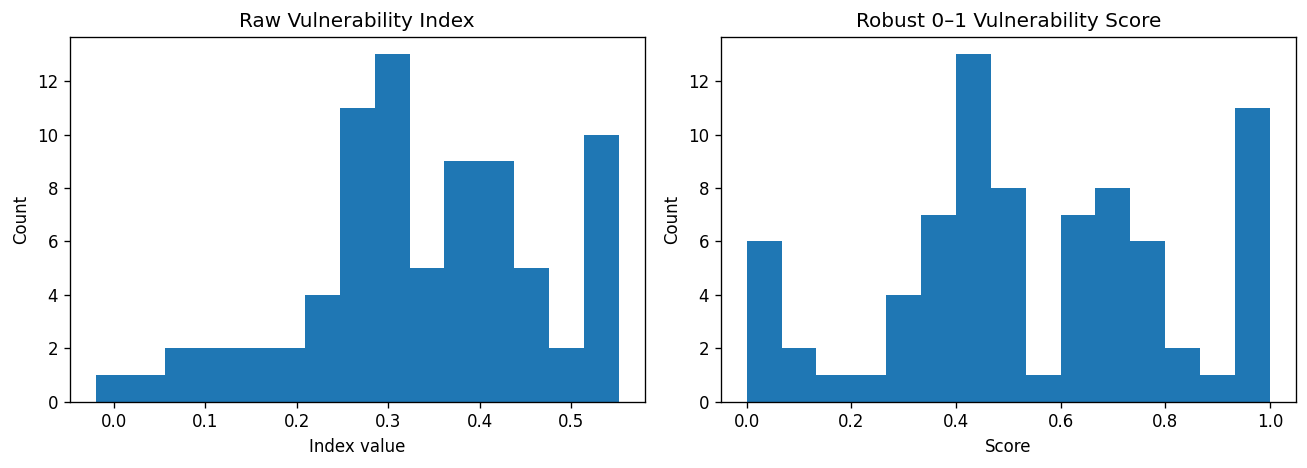

,municipio,vulnerability_score_0_1,rank_group
0,Adjuntas,1.000000,Top 5 most vulnerable
1,Vieques,1.000000,Top 5 most vulnerable
2,Guánica,1.000000,Top 5 most vulnerable
3,Peñuelas,1.000000,Top 5 most vulnerable
4,Comerío,0.999233,Top 5 most vulnerable
5,Guaynabo,0.000000,Bottom 5 least vulnerable
6,San Juan,0.000000,Bottom 5 least vulnerable
7,Trujillo Alto,0.000000,Bottom 5 least vulnerable
8,Carolina,0.000000,Bottom 5 least vulnerable
9,Caguas,0.019229,Bottom 5 least vulnerable


Note: percentile clipping improves robustness but can compress the extreme upper tail, so multiple municipalities may share scores near 1.0.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(latest_df["vulnerability_index"].dropna(), bins=15)
axes[0].set_title("Raw Vulnerability Index")
axes[0].set_xlabel("Index value")
axes[0].set_ylabel("Count")

axes[1].hist(latest_df["vulnerability_score_0_1"].dropna(), bins=15)
axes[1].set_title("Robust 0–1 Vulnerability Score")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

vuln_rank_table = pd.concat(
    [
        latest_df[["municipio", "vulnerability_score_0_1"]]
        .sort_values("vulnerability_score_0_1", ascending=False)
        .head(5)
        .assign(rank_group="Top 5 most vulnerable"),
        latest_df[["municipio", "vulnerability_score_0_1"]]
        .sort_values("vulnerability_score_0_1", ascending=True)
        .head(5)
        .assign(rank_group="Bottom 5 least vulnerable"),
    ],
    ignore_index=True,
)

display(vuln_rank_table)

print(
    "Note: percentile clipping improves robustness but can compress the extreme upper tail, "
    "so multiple municipalities may share scores near 1.0."
)



## 4. Select clustering variables

This section builds the municipal feature set used for typology analysis.

The updated workflow now:

- starts from an interpretable candidate set,
- drops variables that are unavailable in the latest-year snapshot,
- removes rows with missing values only for the chosen clustering fields,
- standardizes the retained variables, and
- screens for extremely high pairwise correlation so that one redundant variable does not dominate the clustering solution.

Variables that are constant or near-constant in the selected latest-year snapshot are removed automatically because they cannot contribute to cluster separation.


Candidate clustering columns: ['vulnerability_score_0_1', 'median_income_real', 'income_growth', 'max_wind_knots', 'max_seismic_mag', 'lag_violent_crime_rate', 'lag_property_crime_rate', 'lag_pop_change_1']
Municipal rows retained after NA drop: 78
Constant/near-constant columns removed: ['max_wind_knots']
Highly redundant columns removed (|corr| > 0.90): []
Final clustering columns: ['vulnerability_score_0_1', 'median_income_real', 'income_growth', 'max_seismic_mag', 'lag_violent_crime_rate', 'lag_property_crime_rate', 'lag_pop_change_1']


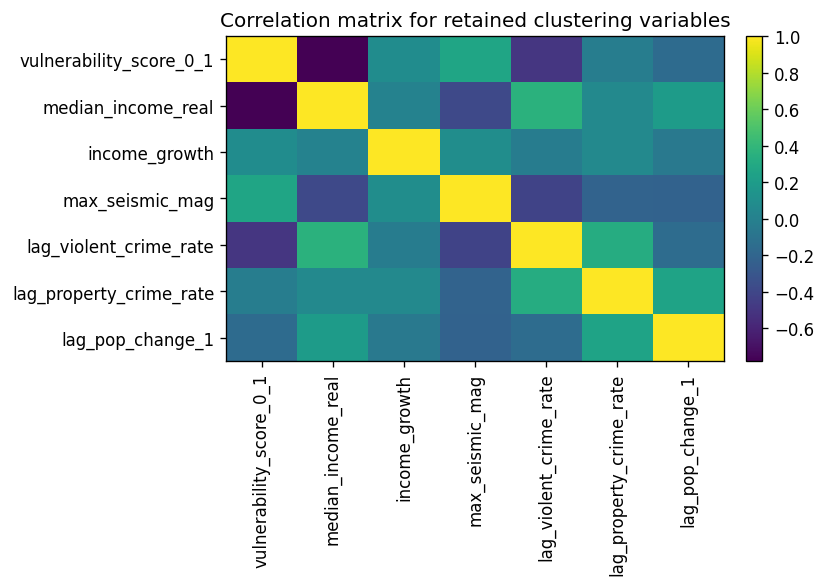

Clustering matrix shape: (78, 7)


In [5]:
preferred_cluster_cols = [
    "vulnerability_score_0_1",
    "median_income_real",
    "income_growth",
    "max_wind_knots",
    "max_seismic_mag",
    "lag_violent_crime_rate",
    "lag_property_crime_rate",
    "lag_pop_change_1",
    "unemployment_rate",
]

cluster_candidates = [c for c in preferred_cluster_cols if c in latest_df.columns]
if len(cluster_candidates) < 3:
    raise ValueError("Need at least 3 available clustering variables in latest-year snapshot.")

cluster_work = latest_df[["municipio"] + cluster_candidates].copy()
cluster_work = cluster_work.dropna().reset_index(drop=True)

print("Candidate clustering columns:", cluster_candidates)
print("Municipal rows retained after NA drop:", cluster_work.shape[0])

# Remove constant or near-constant columns in the selected snapshot because they do not
# help separate municipalities and can create degenerate ANOVA output.
constant_threshold = 1e-12
constant_cols = [
    c for c in cluster_candidates
    if cluster_work[c].nunique(dropna=True) <= 1 or float(cluster_work[c].std(ddof=0)) <= constant_threshold
]
cluster_candidates_nonconstant = [c for c in cluster_candidates if c not in constant_cols]

if len(cluster_candidates_nonconstant) < 3:
    raise ValueError(
        "Fewer than 3 non-constant clustering variables remain after filtering. "
        f"Constant columns detected: {constant_cols}"
    )

corr_abs = cluster_work[cluster_candidates_nonconstant].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
redundant_cols = [col for col in upper.columns if any(upper[col] > 0.90)]
cluster_cols = [c for c in cluster_candidates_nonconstant if c not in redundant_cols]

if len(cluster_cols) < 3:
    cluster_cols = cluster_candidates_nonconstant
    redundant_cols = []

print("Constant/near-constant columns removed:", constant_cols)
print("Highly redundant columns removed (|corr| > 0.90):", redundant_cols)
print("Final clustering columns:", cluster_cols)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cluster_work[cluster_cols].corr(), aspect="auto")
ax.set_xticks(range(len(cluster_cols)))
ax.set_xticklabels(cluster_cols, rotation=90)
ax.set_yticks(range(len(cluster_cols)))
ax.set_yticklabels(cluster_cols)
ax.set_title("Correlation matrix for retained clustering variables")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

latest_df = latest_df.merge(cluster_work[["municipio"] + cluster_cols], on=["municipio"] + cluster_cols, how="inner")
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(latest_df[cluster_cols])

print("Clustering matrix shape:", X_cluster.shape)


## 5. K-means clustering

The earlier notebook inspected only an elbow plot and then fixed the solution at a chosen `k`.

This version adds four diagnostics:

- **inertia** (elbow-style fit)
- **silhouette score** (separation/compactness diagnostic)
- **cluster-size checks** so a high-scoring solution is not accepted blindly if it creates a singleton outlier bucket
- **assignment stability across random seeds**

The notebook therefore distinguishes between:

- the **highest-silhouette** solution, and
- the **preferred substantive solution**, which favors a parsimonious non-singleton typology when the silhouette advantage of a more fragmented solution is small.

That makes the main interpretation more defensible for planning and research write-ups.


/Users/andreruiz/Library/Mobile Documents/com~apple~CloudDocs/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/phase_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreruiz/Library/Mobile Documents/com~apple~CloudDocs/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/phase_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreruiz/Library/Mobile Documents/com~apple~CloudDocs/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/phase_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreruiz/Library/Mobile Documents/com~apple~CloudDocs/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/phase_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andr

Highest-silhouette k: 2
Preferred primary k: 2
Preferred k = 2: non-singleton and within 0.02 of the top silhouette solution (best silhouette k = 2).


/Users/andreruiz/Library/Mobile Documents/com~apple~CloudDocs/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/phase_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreruiz/Library/Mobile Documents/com~apple~CloudDocs/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/phase_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreruiz/Library/Mobile Documents/com~apple~CloudDocs/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/phase_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,k,inertia,silhouette,min_cluster_size,max_cluster_size,singleton_clusters
0,2,410.8437,0.2398,32,46,0
1,3,343.6552,0.2319,19,37,0
2,4,283.2395,0.2394,1,35,1
3,5,243.8539,0.2385,1,25,1
4,6,219.5742,0.2031,1,22,1


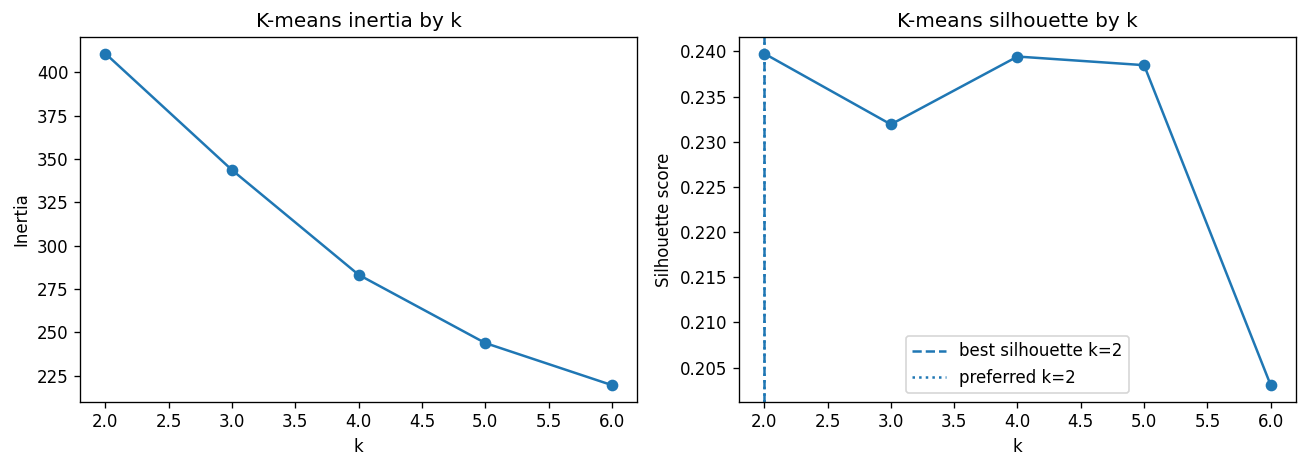

In [6]:
k_values = list(range(2, 7))
cluster_diagnostics = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels)
    counts = pd.Series(labels).value_counts().sort_index()
    cluster_diagnostics.append({
        "k": k,
        "inertia": float(km.inertia_),
        "silhouette": float(sil),
        "min_cluster_size": int(counts.min()),
        "max_cluster_size": int(counts.max()),
        "singleton_clusters": int((counts == 1).sum()),
    })

cluster_diag_df = pd.DataFrame(cluster_diagnostics).sort_values("k").reset_index(drop=True)

best_silhouette = float(cluster_diag_df["silhouette"].max())
best_silhouette_k = int(
    cluster_diag_df.sort_values(["silhouette", "inertia"], ascending=[False, True]).iloc[0]["k"]
)

silhouette_tolerance = 0.02
eligible_diag = cluster_diag_df[
    (cluster_diag_df["singleton_clusters"] == 0)
    & (cluster_diag_df["silhouette"] >= best_silhouette - silhouette_tolerance)
].copy()

if not eligible_diag.empty:
    selected_k = int(eligible_diag.sort_values(["k", "inertia"], ascending=[True, True]).iloc[0]["k"])
    selection_note = (
        f"Preferred k = {selected_k}: non-singleton and within {silhouette_tolerance:.2f} "
        f"of the top silhouette solution (best silhouette k = {best_silhouette_k})."
    )
else:
    selected_k = best_silhouette_k
    selection_note = (
        f"Preferred k falls back to the top silhouette solution because no non-singleton "
        f"alternative was within {silhouette_tolerance:.2f}."
    )

print("Highest-silhouette k:", best_silhouette_k)
print("Preferred primary k:", selected_k)
print(selection_note)
display(cluster_diag_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cluster_diag_df["k"], cluster_diag_df["inertia"], marker="o")
axes[0].set_title("K-means inertia by k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(cluster_diag_df["k"], cluster_diag_df["silhouette"], marker="o")
axes[1].axvline(best_silhouette_k, linestyle="--", label=f"best silhouette k={best_silhouette_k}")
axes[1].axvline(selected_k, linestyle=":", label=f"preferred k={selected_k}")
axes[1].set_title("K-means silhouette by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()

plt.tight_layout()
plt.show()


In [7]:
seed_values = [7, 21, 42, 84, 168]
stability_rows = []

base_kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=20)
base_labels = base_kmeans.fit_predict(X_cluster)
latest_df["kmeans_cluster"] = base_labels

for seed in seed_values:
    km = KMeans(n_clusters=selected_k, random_state=seed, n_init=20)
    labels = km.fit_predict(X_cluster)
    ari = adjusted_rand_score(base_labels, labels)
    stability_rows.append({"seed": seed, "adjusted_rand_vs_seed42": float(ari)})

cluster_stability_df = pd.DataFrame(stability_rows)
display(cluster_stability_df.round(4))
print("Mean K-means stability (ARI):", round(cluster_stability_df["adjusted_rand_vs_seed42"].mean(), 4))

# Keep nearby alternatives for transparency and side-by-side comparison.
alternative_ks = sorted(set([3, 4, best_silhouette_k, selected_k]))
for alt_k in alternative_ks:
    latest_df[f"kmeans_cluster_{alt_k}"] = KMeans(n_clusters=alt_k, random_state=42, n_init=20).fit_predict(X_cluster)

if selected_k != best_silhouette_k:
    print(
        f"Primary interpretation uses k={selected_k}; k={best_silhouette_k} is retained as a sensitivity check."
    )

latest_df[
    ["municipio", "kmeans_cluster"] + [c for c in latest_df.columns if c.startswith("kmeans_cluster_")]
].head()


,seed,adjusted_rand_vs_seed42
0,7,1.0
1,21,1.0
2,42,1.0
3,84,1.0
4,168,1.0


Mean K-means stability (ARI): 1.0


,municipio,kmeans_cluster,kmeans_cluster_2,kmeans_cluster_3,kmeans_cluster_4
0,Adjuntas,0,0,2,1
1,Aguada,0,0,1,2
2,Aguadilla,0,0,2,1
3,Aguas Buenas,0,0,1,2
4,Aibonito,0,0,1,2



## 6. Hierarchical clustering

Hierarchical clustering provides a second view of municipal similarity.

The purpose here is not to force exact agreement with K-means.  
Instead, it helps answer a narrower question: **do the broad municipal groupings appear similar across clustering methods?**


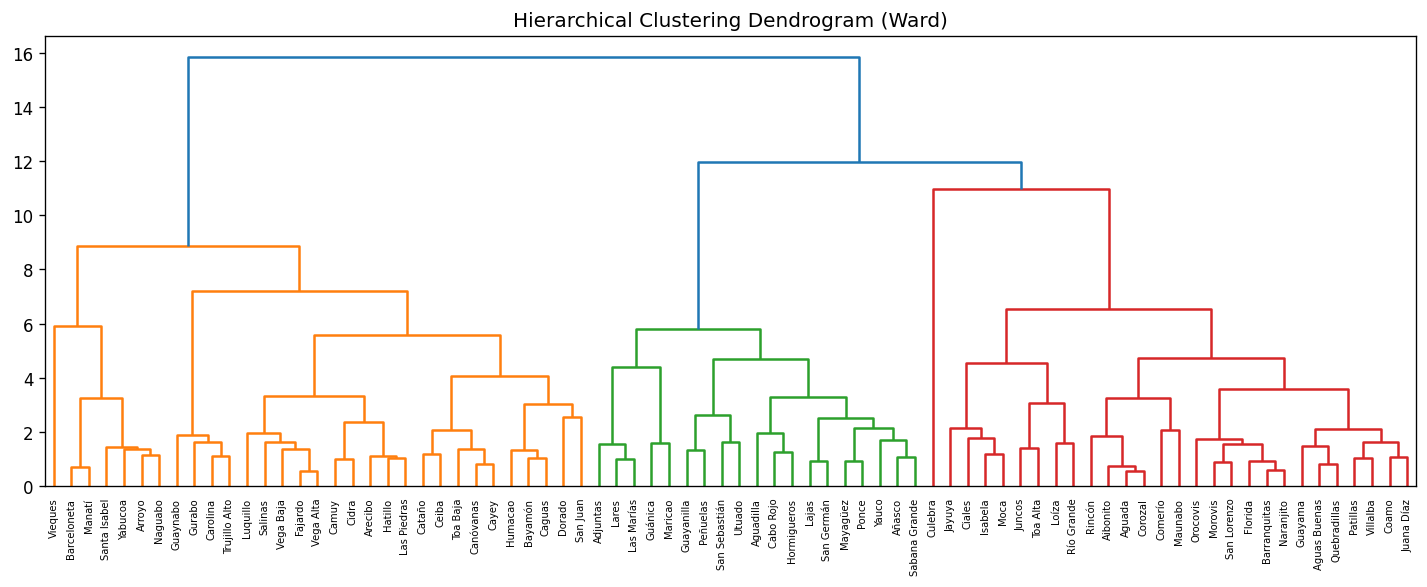

In [8]:

Z = linkage(X_cluster, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=latest_df["municipio"].tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.tight_layout()
plt.show()


In [9]:
latest_df["hier_cluster"] = fcluster(Z, t=selected_k, criterion="maxclust") - 1

hier_ari = adjusted_rand_score(latest_df["kmeans_cluster"], latest_df["hier_cluster"])
print(f"Adjusted Rand Index: primary K-means vs hierarchical (k={selected_k}):", round(float(hier_ari), 4))

comparison_table = pd.crosstab(
    latest_df["kmeans_cluster"],
    latest_df["hier_cluster"],
    rownames=["kmeans_cluster"],
    colnames=["hier_cluster"],
)
comparison_table


Adjusted Rand Index: primary K-means vs hierarchical (k=2): 0.7568


hier_cluster,0,1
kmeans_cluster,,
0,2,44
1,29,3


In [10]:
comparison_cols = ["municipio", "kmeans_cluster", "hier_cluster"]
comparison_cols += [c for c in cluster_cols if c not in comparison_cols]
if "vulnerability_score_0_1" in latest_df.columns and "vulnerability_score_0_1" not in comparison_cols:
    comparison_cols.insert(3, "vulnerability_score_0_1")

comparison_df = (
    latest_df.loc[:, comparison_cols]
    .sort_values(["kmeans_cluster", "municipio"])
    .reset_index(drop=True)
)
comparison_df.head(15)

,municipio,kmeans_cluster,hier_cluster,vulnerability_score_0_1,median_income_real,income_growth,max_seismic_mag,lag_violent_crime_rate,lag_property_crime_rate,lag_pop_change_1
0,Adjuntas,0,1,1.000000,20352.27,2.060950,0.506484,0.166898,0.834492,0.016693
1,Aguada,0,1,0.686009,22384.47,-3.731612,-0.000000,0.131912,0.422119,-0.247381
2,Aguadilla,0,1,0.447936,22425.08,5.529888,0.503083,0.220240,1.027787,-0.485827
3,Aguas Buenas,0,1,0.546310,24020.03,0.221012,-0.000000,0.418620,0.293034,-1.027511
4,Aibonito,0,1,0.600442,22637.46,-2.733270,-0.000000,0.243803,0.528241,0.223987
5,Arroyo,0,0,0.734486,22056.53,8.702657,-0.000000,0.706351,0.642137,-1.417991
6,Añasco,0,1,0.510337,25440.07,0.611697,0.506484,0.237004,0.197504,-0.709887
7,Barranquitas,0,1,0.785310,24368.79,2.566046,-0.000000,0.310516,0.655534,0.294128
8,Cabo Rojo,0,1,0.361287,27493.10,-0.269196,0.506484,0.149079,0.660207,-0.059596
9,Ciales,0,1,0.962155,23514.06,6.424562,-0.000000,0.355577,0.414839,-0.295438


## 7. Municipal typology profiling

This section profiles the selected K-means solution using cluster means and simple difference tests.

Two outputs matter most:

1. **cluster averages** for substantive interpretation, and
2. **ANOVA-style p-values** showing which variables vary most clearly across clusters.

These tests are descriptive rather than causal, but they help identify which dimensions meaningfully differentiate the typology groups.

Because singleton clusters weaken interpretation, the primary solution above is intentionally chosen to avoid that issue when a similarly good non-singleton alternative exists.


In [11]:

typology_profile = latest_df.groupby("kmeans_cluster")[cluster_cols].mean().round(3)
cluster_sizes = latest_df.groupby("kmeans_cluster").size().rename("municipality_count")

anova_rows = []
for col in cluster_cols:
    groups = [g[col].dropna().values for _, g in latest_df.groupby("kmeans_cluster") if g[col].notna().sum() > 1]
    if len(groups) >= 2:
        stat, pval = f_oneway(*groups)
        anova_rows.append({"variable": col, "f_stat": float(stat), "p_value": float(pval)})

anova_df = pd.DataFrame(anova_rows).sort_values("p_value") if anova_rows else pd.DataFrame(columns=["variable", "f_stat", "p_value"])

print("Cluster sizes:")
display(cluster_sizes)
print("Cluster mean profiles:")
display(typology_profile)
print("Variables that most clearly differentiate clusters:")
display(anova_df.round(4))


Cluster sizes:


kmeans_cluster
0    46
1    32
Name: municipality_count, dtype: int64

Cluster mean profiles:


,vulnerability_score_0_1,median_income_real,income_growth,max_seismic_mag,lag_violent_crime_rate,lag_property_crime_rate,lag_pop_change_1
kmeans_cluster,,,,,,,
0,0.689,23079.380,2.647,0.209,0.240,0.527,-0.634
1,0.334,30221.636,2.415,0.000,0.606,0.908,-0.206


Variables that most clearly differentiate clusters:


,variable,f_stat,p_value
4,lag_violent_crime_rate,74.2374,0.0000
0,vulnerability_score_0_1,50.7761,0.0000
1,median_income_real,44.8164,0.0000
3,max_seismic_mag,21.9410,0.0000
5,lag_property_crime_rate,20.1696,0.0000
6,lag_pop_change_1,2.5740,0.1128
2,income_growth,0.0505,0.8228


In [12]:
profile_z = (typology_profile - typology_profile.mean()) / typology_profile.std(ddof=0).replace(0, np.nan)


def assign_typology_label(profile_row):
    vuln = profile_row.get("vulnerability_score_0_1", 0)
    pop_change = profile_row.get("lag_pop_change_1", 0)
    income = profile_row.get("median_income_real", 0)
    unemployment = profile_row.get("unemployment_rate", 0)
    violent = profile_row.get("lag_violent_crime_rate", np.nan)

    income_median = typology_profile["median_income_real"].median() if "median_income_real" in typology_profile.columns else np.nan
    unemployment_median = typology_profile["unemployment_rate"].median() if "unemployment_rate" in typology_profile.columns else np.nan
    violent_median = typology_profile["lag_violent_crime_rate"].median() if "lag_violent_crime_rate" in typology_profile.columns else np.nan

    income_high = pd.notna(income_median) and income >= income_median
    unemployment_high = pd.notna(unemployment_median) and unemployment >= unemployment_median
    violent_high = pd.notna(violent_median) and pd.notna(violent) and violent >= violent_median

    if vuln >= 0.60 and pop_change < 0 and not income_high:
        return "Higher-vulnerability, lower-income declining municipalities"
    if income_high and vuln < 0.50 and pop_change >= typology_profile["lag_pop_change_1"].median():
        return "Relatively stable, higher-income municipalities"
    if unemployment_high and vuln >= 0.50:
        return "Economically constrained, higher-vulnerability municipalities"
    if violent_high and income_high:
        return "Higher-income municipalities with elevated violent-crime exposure"
    return "Mixed-transition municipalities"


label_rows = []
for cluster_id, row in typology_profile.iterrows():
    label_rows.append({
        "kmeans_cluster": cluster_id,
        "typology_label": assign_typology_label(row),
    })

cluster_label_df = pd.DataFrame(label_rows)
latest_df = latest_df.merge(cluster_label_df, on="kmeans_cluster", how="left")

typology_profile_labeled = (
    typology_profile
    .reset_index()
    .merge(cluster_label_df, on="kmeans_cluster", how="left")
    .merge(cluster_sizes.reset_index(), on="kmeans_cluster", how="left")
)

# Add a compact narrative helper based on the strongest differentiators.
top_differentiators = anova_df["variable"].head(3).tolist() if not anova_df.empty else []
cluster_takeaway_rows = []
for _, row in typology_profile_labeled.iterrows():
    takeaways = []
    if "vulnerability_score_0_1" in typology_profile_labeled.columns:
        takeaways.append(f"vulnerability={row['vulnerability_score_0_1']:.3f}")
    if "median_income_real" in typology_profile_labeled.columns:
        takeaways.append(f"income={row['median_income_real']:.0f}")
    if "lag_pop_change_1" in typology_profile_labeled.columns:
        takeaways.append(f"recent pop change={row['lag_pop_change_1']:.3f}")
    cluster_takeaway_rows.append({
        "kmeans_cluster": row["kmeans_cluster"],
        "typology_label": row["typology_label"],
        "municipality_count": row["municipality_count"],
        "summary": ", ".join(takeaways),
    })

cluster_takeaway_df = pd.DataFrame(cluster_takeaway_rows)

print("Top differentiating variables:", top_differentiators if top_differentiators else "not available")
display(typology_profile_labeled)
display(cluster_takeaway_df)

Top differentiating variables: ['lag_violent_crime_rate', 'vulnerability_score_0_1', 'median_income_real']


,kmeans_cluster,vulnerability_score_0_1,median_income_real,income_growth,max_seismic_mag,lag_violent_crime_rate,lag_property_crime_rate,lag_pop_change_1,typology_label,municipality_count
0,0,0.689,23079.380,2.647,0.209,0.240,0.527,-0.634,"Higher-vulnerability, lower-income declining m...",46
1,1,0.334,30221.636,2.415,0.000,0.606,0.908,-0.206,"Relatively stable, higher-income municipalities",32


,kmeans_cluster,typology_label,municipality_count,summary
0,0,"Higher-vulnerability, lower-income declining m...",46,"vulnerability=0.689, income=23079, recent pop ..."
1,1,"Relatively stable, higher-income municipalities",32,"vulnerability=0.334, income=30222, recent pop ..."


## 8. Explicit net migration modeling

If birth and death fields are available, this section estimates a simple **net migration proxy**:

`net migration ≈ population change − natural change`

The goal is not to recover a full demographic accounting identity.  
Instead, the purpose is to connect the new typology layer to a migration-oriented signal that can be compared across clusters.

When births/deaths are not available in the processed panel, the notebook now records that status explicitly and treats migration modeling as **deferred rather than completed**.


In [13]:
birth_candidates = [c for c in latest_df.columns if "birth" in c.lower()]
death_candidates = [c for c in latest_df.columns if "death" in c.lower()]

net_migration_status = "not_available"
cluster_migration_profile = pd.DataFrame()
migration_regression_summary = {}
migration_note = ""

if birth_candidates and death_candidates and "target_pop_change" in latest_df.columns:
    birth_col = birth_candidates[0]
    death_col = death_candidates[0]

    latest_df["net_migration_proxy"] = (
        latest_df["target_pop_change"] - (latest_df[birth_col] - latest_df[death_col])
    )
    net_migration_status = "available"
    migration_note = f"Migration proxy estimated using {birth_col} and {death_col}."

    cluster_migration_profile = (
        latest_df.groupby(["kmeans_cluster", "typology_label"])["net_migration_proxy"]
        .agg(["mean", "median", "min", "max", "count"])
        .round(3)
        .reset_index()
    )
    display(cluster_migration_profile)

    reg_features = [c for c in ["vulnerability_score_0_1", "median_income_real", "unemployment_rate"] if c in latest_df.columns]
    if reg_features and latest_df[reg_features + ["net_migration_proxy"]].dropna().shape[0] >= max(10, len(reg_features) + 2):
        reg_df = latest_df[reg_features + ["net_migration_proxy"]].dropna().copy()
        X_reg = reg_df[reg_features].values
        y_reg = reg_df["net_migration_proxy"].values
        reg = LinearRegression().fit(X_reg, y_reg)
        migration_regression_summary = {
            "features": reg_features,
            "intercept": float(reg.intercept_),
            "coefficients": {feat: float(coef) for feat, coef in zip(reg_features, reg.coef_)},
            "r_squared_in_sample": float(reg.score(X_reg, y_reg)),
        }
        print("Migration proxy regression summary:")
        print(json.dumps(migration_regression_summary, indent=2))
else:
    net_migration_status = "deferred_missing_birth_death_fields"
    migration_note = (
        "Birth/death fields were not available in the processed panel, so migration modeling "
        "is explicitly deferred in this run."
    )
    print(migration_note)


Birth/death fields were not available in the processed panel, so migration modeling is explicitly deferred in this run.


## 9. Export typology outputs

The exported files now preserve the **primary cluster solution** used for interpretation while also keeping nearby alternatives (such as the top-silhouette solution) for sensitivity checks.


In [14]:
typology_out = analysis_dir / "municipal_typologies_latest_year.csv"
profile_out = analysis_dir / "municipal_typology_profiles.csv"
summary_out = analysis_dir / "phase5_typology_summary.json"
stability_out = analysis_dir / "phase5_cluster_diagnostics.csv"
comparison_out = analysis_dir / "phase5_cluster_assignments.csv"
anova_out = analysis_dir / "phase5_typology_anova.csv"

export_cols = [
    "municipio",
    "year",
    "vulnerability_index",
    "vulnerability_score_0_1",
    "kmeans_cluster",
    "hier_cluster",
    "typology_label",
]
export_cols += [c for c in latest_df.columns if c.startswith("kmeans_cluster_")]
export_cols += [c for c in cluster_cols if c not in export_cols]
if "net_migration_proxy" in latest_df.columns and "net_migration_proxy" not in export_cols:
    export_cols.append("net_migration_proxy")

# Preserve order while removing duplicates.
export_cols = list(dict.fromkeys([c for c in export_cols if c in latest_df.columns]))

latest_df[export_cols].to_csv(typology_out, index=False)
typology_profile_labeled.to_csv(profile_out, index=False)
cluster_diag_df.to_csv(stability_out, index=False)
comparison_df.to_csv(comparison_out, index=False)
anova_df.to_csv(anova_out, index=False)

phase5_summary = {
    "latest_year": latest_year,
    "recent_years_checked": [int(y) for y in recent_years],
    "snapshot_stability": snapshot_stability_df.to_dict(orient="records"),
    "year_sensitive_variables": year_sensitive_vars,
    "cluster_columns": cluster_cols,
    "constant_columns_removed": constant_cols,
    "redundant_columns_removed": redundant_cols,
    "best_silhouette_k": best_silhouette_k,
    "selected_k": selected_k,
    "selection_note": selection_note,
    "top_differentiating_variables": top_differentiators,
    "kmeans_diagnostics": cluster_diag_df.round(6).to_dict(orient="records"),
    "kmeans_stability_mean_ari": float(cluster_stability_df["adjusted_rand_vs_seed42"].mean()),
    "kmeans_vs_hierarchical_ari": float(hier_ari),
    "net_migration_status": net_migration_status,
    "migration_note": migration_note,
    "migration_regression_summary": migration_regression_summary,
    "export_files": {
        "typology_output_csv": str(typology_out),
        "profile_output_csv": str(profile_out),
        "cluster_diagnostics_csv": str(stability_out),
        "cluster_assignments_csv": str(comparison_out),
        "anova_output_csv": str(anova_out),
    },
}

with open(summary_out, "w", encoding="utf-8") as f:
    json.dump(phase5_summary, f, indent=2)

print("Saved:")
print(" -", typology_out)
print(" -", profile_out)
print(" -", stability_out)
print(" -", comparison_out)
print(" -", anova_out)
print(" -", summary_out)


Saved:
 - municipal_typologies_latest_year.csv
 - municipal_typology_profiles.csv
 - phase5_cluster_diagnostics.csv
 - phase5_cluster_assignments.csv
 - phase5_typology_anova.csv
 - phase5_typology_summary.json


# Phase 5 Conclusion: Municipal Typology, Vulnerability Scoring, and Structural Classification

Phase 5 should be understood as a **stable municipal typology workflow**, rather than a simple clustering exercise.

A central improvement in this phase is that the latest-year snapshot is no longer assumed to be automatically representative of deeper municipal structure. Instead, the notebook compares the most recent cross-section with recent-year municipal averages and explicitly flags variables that appear more year-sensitive. This distinction helps separate relatively durable structural dimensions, such as vulnerability and income, from more volatile momentum measures, such as lagged population change.

The vulnerability score is also more defensible in this version. By applying percentile clipping before 0–1 scaling, the notebook produces a planner-facing measure that is easier to compare across municipalities without allowing a small number of extreme observations to dominate the full range. At the same time, the approach remains transparent about compressing differences at the upper tail.

Another key improvement is the cleaning of the clustering feature space prior to model estimation. Variables that become constant or near-constant in the selected snapshot are automatically removed, since they cannot contribute to meaningful separation and can generate degenerate inferential output. After this step, the notebook also evaluates redundancy among the remaining features, producing a more coherent and interpretable clustering input set.

Cluster selection is handled using multiple diagnostics rather than a single rule. The notebook combines inertia, silhouette scores, cluster-size checks, and seed-stability diagnostics to determine a **preferred primary solution**. In this case, the selected solution (k = 2) is highly stable across random seeds and avoids the singleton-cluster issue observed in higher-k alternatives. A marginally higher silhouette score is therefore not treated as decisive when it depends on a fragmented cluster structure.

As a result, interpretation should focus on the **selected primary k = 2 typology**, while higher-silhouette alternatives (such as k = 4) that generate singleton clusters are treated only as sensitivity checks. This approach makes the typology more defensible for use in the research paper, dashboard, and municipality profile outputs.

The cluster outputs themselves are now more interpretable and useful. The notebook provides:
- cluster mean profiles,
- ANOVA-style differentiator tests,
- clean comparison exports without duplicated fields, and
- typology labels that are closer to planner-facing language.

These additions make the typology easier to communicate and more practical for downstream applications.

The migration section remains transparent about its scope. When births and deaths are unavailable in the processed dataset, migration modeling is explicitly recorded as **deferred in this run**, rather than implied or overstated.

Substantively, Phase 5 should be presented as a **descriptive classification layer rather than a causal model**. This framing also connects directly to Phases 2–4. When forecasting performance remains limited and much of the predictive signal is driven by lagged population change, a municipal typology can still reveal durable structural heterogeneity across Puerto Rico’s municipalities. In this sense, Phase 5 adds value by organizing municipalities into interpretable structural groupings that support planning, dashboard interpretation, and case selection.